In [1]:
import numpy as np

In [2]:
import pandas as pd

In [93]:
import matplotlib.pyplot as plt

In [108]:
ansiedad = pd.read_csv('social_media_mental_health.csv')

In [109]:
ansiedad

,ID,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,1,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,2,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,3,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,4,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,5,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,U-d426a474,21,Female,Hyper-Connected,TikTok,5.62,Gaming,Active,1,0,5.7,6,Mild,10,Moderate
7996,7997,U-d96fd8b6,18,Male,Digital Minimalist,YouTube,3.15,News/Politics,Active,0,0,6.3,0,Minimal,12,Moderate
7997,7998,U-d3fdaa9b,18,Male,Hyper-Connected,YouTube,7.47,Gaming,Active,1,0,6.1,12,Moderate,14,Moderate
7998,7999,U-128befb0,18,Female,Hyper-Connected,Instagram,8.45,Self-Help/Motivation,Active,0,1,4.3,11,Moderate,2,None-Minimal


# 0.0 Correlación Pearson Horas en pantalla vs Severidad

In [91]:
correlacion_0 = ansiedad["Daily_Screen_Time_Hours"].corr(ansiedad["GAD_7_Score"])

In [92]:
print(correlacion_0)

0.6319324556559017


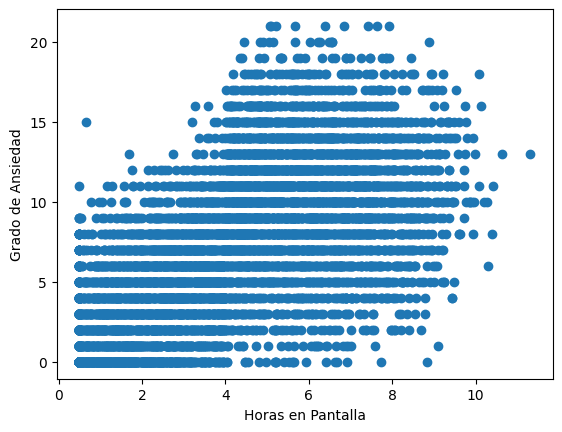

In [103]:
plt.scatter(ansiedad["Daily_Screen_Time_Hours"], ansiedad["GAD_7_Score"])
plt.xlabel("Horas en Pantalla")
plt.ylabel("Grado de Ansiedad")
plt.show()

# 0.1 Correlación Pearson Horas de dormir vs Severidad

In [104]:
correlacion_1 = ansiedad["Sleep_Duration_Hours"].corr(ansiedad["GAD_7_Score"])

In [105]:
print(correlacion_1)

-0.4397340666173295


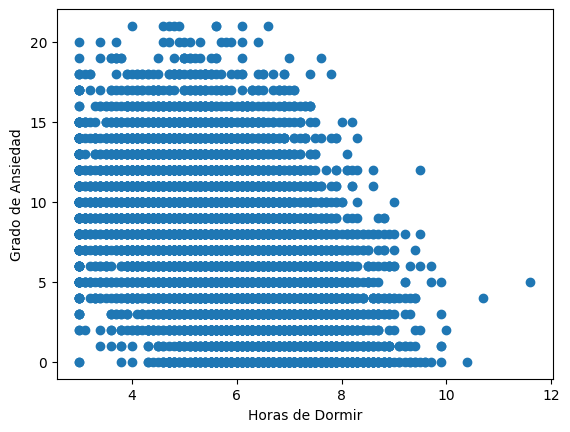

In [106]:
plt.scatter(ansiedad["Sleep_Duration_Hours"], ansiedad["GAD_7_Score"])
plt.xlabel("Horas de Dormir")
plt.ylabel("Grado de Ansiedad")
plt.show()

# 0.2 Correlación Pearson Horas en pantalla vs Horas de dormir

In [89]:
correlacion_2 = ansiedad["Daily_Screen_Time_Hours"].corr(ansiedad["Sleep_Duration_Hours"])

In [90]:
print(correlacion_2)

-0.6842311787020766


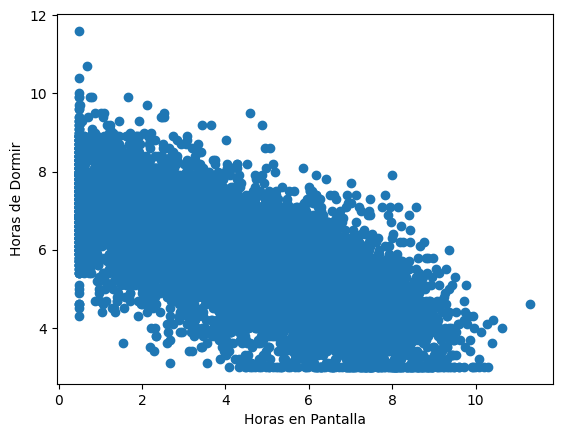

In [107]:
plt.scatter(ansiedad["Daily_Screen_Time_Hours"], ansiedad["Sleep_Duration_Hours"])
plt.xlabel("Horas en Pantalla")
plt.ylabel("Horas de Dormir")
plt.show()

 # 1.- Grado de ansiedad severo (mayores o iguales a 15)

In [5]:
ansiedad_1 = ansiedad[(ansiedad['GAD_7_Score'] >= 15)]

In [6]:
ansiedad_1['Late_Night_Usage'].value_counts()

Late_Night_Usage
1    510
0     35
Name: count, dtype: int64

In [7]:
ansiedad_1['User_Archetype'].value_counts()

User_Archetype
Passive Scroller      286
Hyper-Connected       205
Average User           51
Digital Minimalist      3
Name: count, dtype: int64

## 1.1.- Caso de ansiedad con uso en media noche y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [25]:
ansiedad_1_1 = ansiedad[(ansiedad['GAD_7_Score'] >= 15) & (ansiedad['Late_Night_Usage'] == 1) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [26]:
ansiedad_1_1['Late_Night_Usage'].value_counts()

Late_Night_Usage
1    462
Name: count, dtype: int64

In [27]:
ansiedad_1_1['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Self-Help/Motivation    112
Lifestyle/Fashion       100
Gaming                   68
News/Politics            64
Entertainment/Comedy     62
Educational/Tech         56
Name: count, dtype: int64

In [28]:
ansiedad_1_1['Primary_Platform'].value_counts()

Primary_Platform
TikTok       105
Instagram     96
Facebook      58
Snapchat      57
Twitter/X     55
YouTube       48
LinkedIn      43
Name: count, dtype: int64

In [266]:
ansiedad_1_1_1 = ansiedad_1_1[(ansiedad_1_1['Daily_Screen_Time_Hours'] >= 4) & (ansiedad_1_1['Daily_Screen_Time_Hours'] <= 9)]

In [267]:
ansiedad_1_1_1['Dominant_Content_Type'].value_counts().sum()

np.int64(446)

## 1.2.- Caso de ansiedad con uso de día y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [122]:
ansiedad_1_2 = ansiedad[(ansiedad['GAD_7_Score'] >= 15) & (ansiedad['Late_Night_Usage'] == 0) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [123]:
ansiedad_1_2['Late_Night_Usage'].value_counts()

Late_Night_Usage
0    29
Name: count, dtype: int64

In [124]:
ansiedad_1_2['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Self-Help/Motivation    11
Lifestyle/Fashion        7
News/Politics            5
Educational/Tech         3
Entertainment/Comedy     3
Name: count, dtype: int64

In [125]:
ansiedad_1_2['Primary_Platform'].value_counts()

Primary_Platform
Instagram    11
TikTok        7
Snapchat      4
YouTube       3
Twitter/X     2
Facebook      1
LinkedIn      1
Name: count, dtype: int64

In [264]:
ansiedad_1_2_1 = ansiedad_1_2[(ansiedad_1_2['Daily_Screen_Time_Hours'] >= 5) & (ansiedad_1_2['Daily_Screen_Time_Hours'] <= 10)]

In [265]:
ansiedad_1_2_1['Primary_Platform'].value_counts().sum()

np.int64(19)

# 2.-Grado de ansiedad moderado (mayores a 10 y menores a 15)

In [90]:
ansiedad_2 = ansiedad[(ansiedad['GAD_7_Score'] >= 10) & (ansiedad['GAD_7_Score'] < 15)]

In [91]:
ansiedad_2['Late_Night_Usage'].value_counts()

Late_Night_Usage
1    1656
0     489
Name: count, dtype: int64

In [92]:
ansiedad_2['User_Archetype'].value_counts()

User_Archetype
Hyper-Connected       944
Passive Scroller      820
Average User          332
Digital Minimalist     49
Name: count, dtype: int64

## 2.1.- Caso de ansiedad con uso en media noche y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [150]:
ansiedad_2_1 = ansiedad[((ansiedad['GAD_7_Score'] >= 10) & (ansiedad['GAD_7_Score'] < 15)) & (ansiedad['Late_Night_Usage'] == 1) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [151]:
ansiedad_2_1['Late_Night_Usage'].value_counts()

Late_Night_Usage
1    1420
Name: count, dtype: int64

In [152]:
ansiedad_2_1['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Educational/Tech        272
News/Politics           241
Entertainment/Comedy    236
Gaming                  232
Lifestyle/Fashion       228
Self-Help/Motivation    211
Name: count, dtype: int64

In [153]:
ansiedad_2_1['Primary_Platform'].value_counts()

Primary_Platform
Instagram    216
Snapchat     214
Twitter/X    213
YouTube      208
LinkedIn     193
Facebook     191
TikTok       185
Name: count, dtype: int64

In [276]:
ansiedad_2_1_1 = ansiedad_2_1[(ansiedad_2_1['Daily_Screen_Time_Hours'] >= 5) & (ansiedad_2_1['Daily_Screen_Time_Hours'] <= 9)]

In [277]:
ansiedad_2_1_1['Primary_Platform'].value_counts().sum()

np.int64(1118)

## 2.2.- Caso de ansiedad con uso de día y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [142]:
ansiedad_2_2 = ansiedad[((ansiedad['GAD_7_Score'] >= 10) & (ansiedad['GAD_7_Score'] < 15)) & (ansiedad['Late_Night_Usage'] == 0) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [143]:
ansiedad_2_2['Late_Night_Usage'].value_counts()

Late_Night_Usage
0    344
Name: count, dtype: int64

In [144]:
ansiedad_2_2['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Self-Help/Motivation    78
Lifestyle/Fashion       69
Gaming                  59
News/Politics           54
Entertainment/Comedy    50
Educational/Tech        34
Name: count, dtype: int64

In [145]:
ansiedad_2_2['Primary_Platform'].value_counts()

Primary_Platform
TikTok       68
Instagram    62
YouTube      49
Twitter/X    46
Snapchat     43
LinkedIn     41
Facebook     35
Name: count, dtype: int64

In [284]:
ansiedad_2_2_1 = ansiedad_2_2[(ansiedad_2_2['Daily_Screen_Time_Hours'] >= 4) & (ansiedad_2_2['Daily_Screen_Time_Hours'] <= 9)]

In [285]:
ansiedad_2_2_1['Primary_Platform'].value_counts().sum()

np.int64(266)

# Grado de ansiedad leve (mayores a 5 y menores a 10)

In [172]:
ansiedad_3 = ansiedad[(ansiedad['GAD_7_Score'] >= 5) & (ansiedad['GAD_7_Score'] < 10)]

In [173]:
ansiedad_3['Late_Night_Usage'].value_counts()

Late_Night_Usage
0    2073
1     818
Name: count, dtype: int64

In [174]:
ansiedad_3['User_Archetype'].value_counts()

User_Archetype
Average User          883
Hyper-Connected       764
Passive Scroller      641
Digital Minimalist    603
Name: count, dtype: int64

## 3.1.- Caso de ansiedad con uso en media noche y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [198]:
ansiedad_3_1 = ansiedad[((ansiedad['GAD_7_Score'] >= 5) & (ansiedad['GAD_7_Score'] < 10)) & (ansiedad['Late_Night_Usage'] == 1) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [199]:
ansiedad_3_1['Late_Night_Usage'].value_counts()

Late_Night_Usage
1    604
Name: count, dtype: int64

In [200]:
ansiedad_3_1['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Entertainment/Comedy    118
News/Politics           114
Educational/Tech        111
Gaming                   97
Self-Help/Motivation     96
Lifestyle/Fashion        68
Name: count, dtype: int64

In [201]:
ansiedad_3_1['Primary_Platform'].value_counts().sum()

np.int64(604)

In [215]:
ansiedad_3_1_1 = ansiedad_3_1[(ansiedad_3_1['Sleep_Duration_Hours'] >= 3) & (ansiedad_3_1['Sleep_Duration_Hours'] <= 7)]

In [216]:
ansiedad_3_1_1['Primary_Platform'].value_counts().sum()

np.int64(584)

## 3.2.- Caso de ansiedad con uso de día y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [202]:
ansiedad_3_2 = ansiedad[((ansiedad['GAD_7_Score'] >= 5) & (ansiedad['GAD_7_Score'] < 10)) & (ansiedad['Late_Night_Usage'] == 0) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [203]:
ansiedad_3_2['Late_Night_Usage'].value_counts()

Late_Night_Usage
0    801
Name: count, dtype: int64

In [189]:
ansiedad_3_2['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Entertainment/Comedy    153
Gaming                  144
Lifestyle/Fashion       137
Educational/Tech        137
Self-Help/Motivation    122
News/Politics           108
Name: count, dtype: int64

In [192]:
ansiedad_3_2['Primary_Platform'].value_counts().sum()

np.int64(801)

In [226]:
ansiedad_3_2_1 = ansiedad_3_2[(ansiedad_3_2['Sleep_Duration_Hours'] >= 3) & (ansiedad_3_2['Sleep_Duration_Hours'] <= 7)]

In [227]:
ansiedad_3_2_1['Primary_Platform'].value_counts().sum()

np.int64(746)

# 4.- Grado de ansiedad ligera (menores a 5)

In [64]:
ansiedad_4 = ansiedad[(ansiedad['GAD_7_Score'] < 5)]

In [65]:
ansiedad_4['Late_Night_Usage'].value_counts()

Late_Night_Usage
0    2368
1      51
Name: count, dtype: int64

In [66]:
ansiedad_4['User_Archetype'].value_counts()

User_Archetype
Digital Minimalist    1375
Average User           727
Passive Scroller       162
Hyper-Connected        155
Name: count, dtype: int64

## 4.1.- Caso de ansiedad con uso en media noche y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [288]:
ansiedad_4_1 = ansiedad[(ansiedad['GAD_7_Score'] < 5) & (ansiedad['Late_Night_Usage'] == 1) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [289]:
ansiedad_4_1['Late_Night_Usage'].value_counts()

Late_Night_Usage
1    31
Name: count, dtype: int64

In [290]:
ansiedad_4_1['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Educational/Tech        9
News/Politics           7
Self-Help/Motivation    5
Gaming                  5
Entertainment/Comedy    4
Lifestyle/Fashion       1
Name: count, dtype: int64

In [291]:
ansiedad_4_1['Primary_Platform'].value_counts()

Primary_Platform
Facebook     7
Instagram    6
LinkedIn     5
Snapchat     5
Twitter/X    4
YouTube      3
TikTok       1
Name: count, dtype: int64

## 4.2.- Caso de ansiedad con uso de día y arqutipos de usuario "Passive Scroller" y " Hyper Connected"

In [286]:
ansiedad_4_2 = ansiedad[(ansiedad['GAD_7_Score'] < 5)  & (ansiedad['Late_Night_Usage'] == 0) &
    ((ansiedad['User_Archetype'] == 'Passive Scroller') | (ansiedad['User_Archetype'] == 'Hyper-Connected'))]

In [287]:
ansiedad_4_2['Late_Night_Usage'].value_counts()

Late_Night_Usage
0    286
Name: count, dtype: int64

In [230]:
ansiedad_4_2['Dominant_Content_Type'].value_counts()

Dominant_Content_Type
Entertainment/Comedy    153
Gaming                  144
Lifestyle/Fashion       137
Educational/Tech        137
Self-Help/Motivation    122
News/Politics           108
Name: count, dtype: int64

In [233]:
ansiedad_4_2_1 = ansiedad_4_2[(ansiedad_4_2['Sleep_Duration_Hours'] >= 3) & (ansiedad_4_2['Sleep_Duration_Hours'] <= 8)]

In [234]:
ansiedad_4_2_1['Primary_Platform'].value_counts().sum()

np.int64(791)